In [3]:
import torch
import numpy as np
import pandas as pd

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader,TensorDataset #do koncowego przygotowania danych
import pysam
import yfinance as yf #do danych finansowych

from sklearn.preprocessing import MinMaxScaler #do skalowania

from sklearn.metrics import classification_report #do robienia raportów o uczeniu

import matplotlib.pyplot as plt

import seaborn as sns
import statsmodels.api as sm

import optuna
from optuna.trial import TrialState
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

import sys
sys.path.append('..')
import funkcje


device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [4]:
data=yf.download("BTC-USD", start="2014-01-01", interval="1d",auto_adjust=True)
data=funkcje.funkcja_do_danych(data)


[*********************100%***********************]  1 of 1 completed


In [5]:
class autocoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, seq_len, latent_dim, dropout=0.0):
        super().__init__()
        self.seq_len = seq_len
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.latent_dim = latent_dim
        
        self.encoder_lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0)
        
        
        self.hidden_to_latent = nn.Linear(hidden_size, latent_dim)
        self.relu = nn.ReLU() 

        # --- DECODER ---
      
        self.latent_to_hidden = nn.Linear(latent_dim, hidden_size)
        
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_size, # Wchodzimy stanem ukrytym
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.output_layer = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        _, (hidden_n, _) = self.encoder_lstm(x)
        last_hidden_state = hidden_n[-1]
        latent_vector = self.relu(self.hidden_to_latent(last_hidden_state))
        decoder_hidden = self.latent_to_hidden(latent_vector)
        decoder_input = decoder_hidden.unsqueeze(1).repeat(1, self.seq_len, 1)
        decoder_output, _ = self.decoder_lstm(decoder_input)
        reconstructed = self.output_layer(decoder_output)
        
        return reconstructed

    def get_latent(self, x):
        with torch.no_grad():
            _, (hidden_n, _) = self.encoder_lstm(x)
            last_hidden_state = hidden_n[-1]
            latent_vector = self.relu(self.hidden_to_latent(last_hidden_state))
        return latent_vector

In [6]:

def objective(trial):
  
    latent_dim = trial.suggest_int("latent_dim", 4, 24)
    hidden_size = trial.suggest_int("hidden_size", 32, 128)
    num_layers = trial.suggest_int("num_layers", 1, 2)
    learning_rate = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)

    SEQ_LEN = trial.suggest_int("seq_len", 15, 60)

    BATCH_SIZE = trial.suggest_categorical("batch_size", [128, 256])

    EPOCHS = 30 
    
 
    INPUT_SIZE = data.shape[1]

    split_idx = int(len(data) * 0.8)
    

    train_x_raw = data.iloc[:split_idx].values
    val_x_raw   = data.iloc[split_idx:].values


    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_x_scaled = scaler.fit_transform(train_x_raw)
    val_x_scaled   = scaler.transform(val_x_raw)


    train_seq_x, _ = funkcje.sekwencje(train_x_scaled, train_x_scaled, SEQ_LEN)
    val_seq_x, _   = funkcje.sekwencje(val_x_scaled, val_x_scaled, SEQ_LEN)

    train_tensor = torch.tensor(train_seq_x, dtype=torch.float32)
    val_tensor   = torch.tensor(val_seq_x, dtype=torch.float32)


    train_loader = DataLoader(
        TensorDataset(train_tensor, train_tensor),
        batch_size=BATCH_SIZE,
        shuffle=True, 
        num_workers=2, 
        persistent_workers=True
      
    )

    val_loader = DataLoader(
        TensorDataset(val_tensor, val_tensor),
        batch_size=BATCH_SIZE,
        shuffle=False, 
        num_workers=2,
        persistent_workers=True

    )

  
    model = autocoder(
        INPUT_SIZE, hidden_size, num_layers, SEQ_LEN, latent_dim, dropout=dropout
    ).to(device)

    optimizer = optim.AdamW(
        model.parameters(), lr=learning_rate, weight_decay=1e-5
    )
    criterion = nn.MSELoss()

 
    for epoch in range(EPOCHS):
        model.train()
        
        for x, target in train_loader:
            x = x.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)

          
            optimizer.zero_grad(set_to_none=True)
            
            output = model(x)
            loss = criterion(output, target)
            
            loss.backward()
            optimizer.step()

 
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, target in val_loader:
                x = x.to(device, non_blocking=True)
                target = target.to(device, non_blocking=True)
                
                output = model(x)
                loss = criterion(output, target)
                val_loss += loss.item()

        val_loss /= len(val_loader)

      
        trial.report(val_loss, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_loss

In [12]:
sampler = TPESampler(seed=42,multivariate=True)

study = optuna.create_study(direction="minimize",sampler=sampler,pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5))
study.optimize(objective, n_trials=30,timeout=None,gc_after_trial=True,show_progress_bar=True) 

print("Najlepszy val_loss:")
print(study.best_value)

print("\nNajlepsze hiperparametry:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")


/opt/anaconda3/envs/DNA_projeckt/lib/python3.10/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-01-05 00:40:43,796] A new study created in memory with name: no-name-d6e83551-9d2c-41c7-b059-632d814d6477
Best trial: 0. Best value: 0.0337122:   3%|▎         | 1/30 [00:09<04:35,  9.49s/it]

[I 2026-01-05 00:40:53,181] Trial 0 finished with value: 0.03371217707172036 and parameters: {'latent_dim': 11, 'hidden_size': 124, 'num_layers': 2, 'lr': 0.0015751320499779737, 'dropout': 0.07800932022121826, 'seq_len': 22, 'batch_size': 256}. Best is trial 0 with value: 0.03371217707172036.


Best trial: 1. Best value: 0.017461:   7%|▋         | 2/30 [00:15<03:27,  7.42s/it] 

[I 2026-01-05 00:40:59,170] Trial 1 finished with value: 0.017460950883105397 and parameters: {'latent_dim': 16, 'hidden_size': 100, 'num_layers': 1, 'lr': 0.008706020878304856, 'dropout': 0.41622132040021087, 'seq_len': 24, 'batch_size': 256}. Best is trial 1 with value: 0.017460950883105397.


Best trial: 2. Best value: 0.0162147:  10%|█         | 3/30 [00:21<02:59,  6.63s/it]

...

[I 2026-01-05 00:48:23,226] Trial 28 pruned. 


Best trial: 26. Best value: 0.0120262:  97%|█████████▋| 29/30 [08:02<00:18, 18.57s/it]

[I 2026-01-05 00:48:46,737] Trial 29 pruned. 


Best trial: 26. Best value: 0.0120262: 100%|██████████| 30/30 [08:23<00:00, 16.77s/it]

Najlepszy val_loss:
0.012026206590235233

Najlepsze hiperparametry:
latent_dim: 10
hidden_size: 113
num_layers: 1
lr: 0.005392141790475265
dropout: 0.43005041256391685
seq_len: 17
batch_size: 128


Epoch 0: Loss 0.06526
Epoch 10: Loss 0.01522
Epoch 20: Loss 0.01346
Epoch 30: Loss 0.01223
Epoch 40: Loss 0.01204


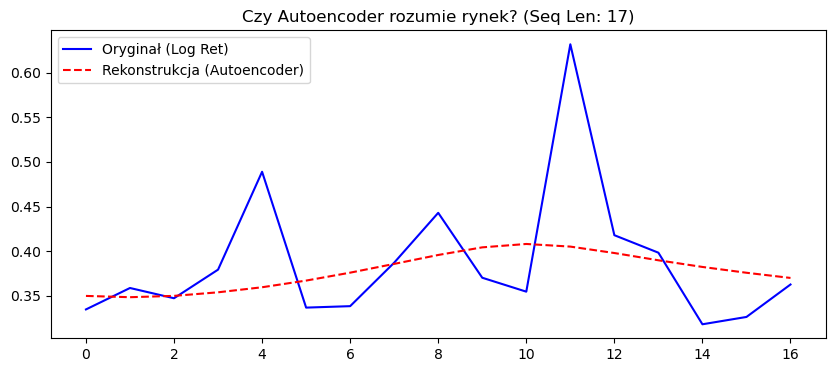

In [13]:
import matplotlib.pyplot as plt

best_params = study.best_params
SEQ_LEN = best_params['seq_len']
BATCH_SIZE = best_params['batch_size']

split_idx = int(len(data) * 0.8)
train_x_raw = data.iloc[:split_idx].values
val_x_raw   = data.iloc[split_idx:].values

scaler = MinMaxScaler(feature_range=(-1, 1))
train_x_scaled = scaler.fit_transform(train_x_raw)
val_x_scaled   = scaler.transform(val_x_raw)

# Generujemy sekwencje
train_seq_x, _ = funkcje.sekwencje(train_x_scaled, train_x_scaled, SEQ_LEN)
val_seq_x, _   = funkcje.sekwencje(val_x_scaled, val_x_scaled, SEQ_LEN)

# Tensors & Loaders
train_tensor = torch.tensor(train_seq_x, dtype=torch.float32)
val_tensor   = torch.tensor(val_seq_x, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(train_tensor, train_tensor), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, persistent_workers=True)
val_loader   = DataLoader(TensorDataset(val_tensor, val_tensor), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, persistent_workers=True)


final_model = autocoder(
    input_size=data.shape[1],
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    seq_len=SEQ_LEN,
    latent_dim=best_params['latent_dim'],
    dropout=best_params['dropout']
).to(device)

optimizer = optim.AdamW(final_model.parameters(), lr=best_params['lr'], weight_decay=1e-5)
criterion = nn.MSELoss()


losses = []
final_model.train()
for epoch in range(50): 
    epoch_loss = 0
    for x, target in train_loader:
        x = x.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        output = final_model(x)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(train_loader))
    if epoch % 10 == 0: print(f"Epoch {epoch}: Loss {losses[-1]:.5f}")

final_model.eval()
with torch.no_grad():
    sample_input = val_tensor[0:1].to(device) 
    reconstructed = final_model(sample_input).cpu().numpy()[0] 
    original = sample_input.cpu().numpy()[0] 


plt.figure(figsize=(10, 4))
plt.plot(original[:, 0], label='Oryginał (Log Ret)', color='blue')
plt.plot(reconstructed[:, 0], label='Rekonstrukcja (Autoencoder)', color='red', linestyle='--')
plt.title(f"Czy Autoencoder rozumie rynek? (Seq Len: {SEQ_LEN})")
plt.legend()
plt.show()


#torch.save(final_model.state_dict(), "best_autoencoder.pth")
#print("Model zapisany jako 'best_autoencoder.pth'")

In [14]:
def get_latent_dataset(model, data_tensor, batch_size=256):
    model.eval()
    latent_features = []
    

    loader = DataLoader(TensorDataset(data_tensor), batch_size=batch_size, shuffle=False)
    
    with torch.no_grad():
        for x in loader:
            x = x[0].to(device)
        
            latent = model.get_latent(x)
            latent_features.append(latent.cpu().numpy())
            
    return np.concatenate(latent_features, axis=0)

full_x_scaled = scaler.transform(data.values) 
full_seq_x, _ = funkcje.sekwencje(full_x_scaled, full_x_scaled, SEQ_LEN)
full_tensor = torch.tensor(full_seq_x, dtype=torch.float32)

X_latent = get_latent_dataset(final_model, full_tensor)


print(f"Stare dane: {full_tensor.shape} (Batch, Czas, Cechy)")
print(f"Nowe dane dla Tradera: {X_latent.shape} (Batch, 22 cechy ukryte)")

Stare dane: torch.Size([4063, 17, 6]) (Batch, Czas, Cechy)
Nowe dane dla Tradera: (4063, 10) (Batch, 22 cechy ukryte)


In [15]:
y_final=data['log_ret'].shift(-1).dropna()
y_final=np.where(y_final>0,1,0)
y_final=y_final[SEQ_LEN-1:]
x_final=X_latent[:-1]

print(len(y_final))
print(x_final.shape)


4062
(4062, 10)


In [16]:
print(x_final,y_final)

[[0.         0.04441187 0.1097407  ... 0.         0.         0.10204034]
 [0.         0.         0.08141531 ... 0.         0.         0.14466287]
 [0.         0.         0.06449416 ... 0.         0.         0.18830726]
 ...
 [0.         0.6820023  0.37143487 ... 0.19637924 0.         0.        ]
 [0.         0.68705857 0.346334   ... 0.21578157 0.         0.        ]
 [0.         0.71541405 0.317842   ... 0.25988212 0.         0.        ]] [1 1 1 ... 1 1 1]


In [17]:
#np.savez_compressed('dane.npz', X=x_final, Y=y_final)